In [1]:
import numpy as np
import pandas as pd
import os
import warnings
import matplotlib.pyplot as plt
from arch import arch_model
from arch.univariate import ARX
import scipy
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
from scipy.stats import kurtosis, skew
from scipy.optimize import minimize

### Import data

In [2]:
path = os.path.abspath('E:/RA/Geert/task1.py')
dir_path = os.path.dirname(path)
os.chdir(dir_path)
excel_file = pd.ExcelFile('Aggregate_CPI_inflation_20230513.xls')
sheet_quarter = excel_file.sheet_names[0]
sheet_month = excel_file.sheet_names[1]
#quarterly and monthly aggregate CPI data (deseasonalized). The full sample is 1947-2022
data_quarter = excel_file.parse(sheet_quarter, skiprows=2)
data_month = excel_file.parse(sheet_month, skiprows=2)
data_quarter.index = pd.to_datetime(data_quarter['Year'].astype(str) + '-Q' + data_quarter['Quarter'].astype(str))
data_month.index = pd.to_datetime(data_month[['Year', 'Month']].assign(day=1))
data_quarter.columns = ['Year', 'Quarter', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
data_month.columns = ['Year', 'Month', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
sample_data = data_quarter[data_quarter['Year']>1969]

In [5]:
sample_data['Inflation_lag_1'] =  sample_data.loc[:,'Inflation'].shift(1)
sample_data['Inflation_lag_2'] =  sample_data.loc[:,'Inflation'].shift(2)
sample_data['Forecasted_inflation_lag_1'] =  sample_data.loc[:,'Forecasted inflation'].shift(1)
sample_data = sample_data.dropna()

 ### Gaussian Mixture distribution

The mixture of 2 normal distribution given parameters $p_1$,$\mu_1$,$\sigma^2_1$ is 
$$
 f\left(z_t\right) =   
 p_1  \frac{1}{\sqrt{ 2\pi\sigma_1^2} } exp\{ -\frac{(z_t-\mu_1)^2}{2\sigma_1^2} \}
+p_2\frac{1}{\sqrt{ 2\pi\sigma_2^2} } exp\{ -\frac{(z_t-\mu_2)^2}{2\sigma_2^2} \}
$$
where $p_2 = 1- p_1 $,$\mu_2 = \frac{-p_1\mu_1}{p_2}$, and
$\sigma_2^2 =\frac{1-p_2\mu_2^2 -p_1(\sigma_1^2 + \mu_1^2 )}{p_2} $

N th order moment can be calculated as:
$$
E[z^n] = \int z^n   \left[p_1 \frac{1}{\sqrt{ 2\pi\sigma_1^2} } exp\{ -\frac{(z-\mu_1)^2}{2\sigma_1^2} \}
+(1-p_1)\frac{1}{\sqrt{ 2\pi\sigma_2^2} } exp\{ -\frac{(z-\mu_2)^2}{2\sigma_2^2} \}  \right] dz
$$

$$
E[z^n] =  p_1 E[x_1^n|x_1 \sim N(\mu_1,\sigma_1^2) ] + p_2 E[x_2^n|x_2 \sim N(\mu_2,\sigma_2^2) ]
$$

Similary, CDF can be calculated analytically by
$$
\Phi(a) = \int_{-\inf}^{a} z   \left[p_1 \frac{1}{\sqrt{ 2\pi\sigma_1^2} } exp\{ -\frac{(z-\mu_1)^2}{2\sigma_1^2} \}
+p_2\frac{1}{\sqrt{ 2\pi\sigma_2^2} } exp\{ -\frac{(z-\mu_2)^2}{2\sigma_2^2} \}  \right] dz
$$

$$
\Phi(a) = p_1\Phi_{x_1}(a) + p_2\Phi_{x_2}(a)
$$

We can think mixture of two normal distributions generated by three random variable $Z$,$X_1$,$X_2$. $Z$ follows Bernoulli($P_1$), $X_1 \sim  N(\mu_1,\sigma_1^2)$ and $X_2 \sim  N(\mu_2,\sigma_2^2)$. In order to generate a random sample point, we can first use $Z$ to decide which normal distributions to use, and then randomly pick a point in that normal distribution. 

Log likelihood function is
$$
 L\left(\epsilon_t\right) =  \sum_{t=1}^{T} \ln \frac{1}{\sqrt{h_t}} \left[
 p_1  \frac{1}{\sqrt{ 2\pi\sigma_1^2} } exp\{ -\frac{(z_t-\mu_1)^2}{2\sigma_1^2} \}
+p_2\frac{1}{\sqrt{ 2\pi\sigma_2^2} } exp\{ -\frac{(z_t-\mu_2)^2}{2\sigma_2^2} \} \right]
$$,
where $z_t = \frac{\epsilon_t}{\sqrt{h_t}}$

In [153]:
from __future__ import annotations
from arch.univariate.distribution import Distribution
from abc import ABCMeta, abstractmethod
from collections.abc import Sequence
from typing import Callable
import warnings

from numpy import (
    abs,    array,    asarray,    empty,    exp,    int64,    
    integer,    isscalar,    log,    nan,    ndarray, exp,
    ones_like,    pi,    sign,    sqrt,    sum, random)
from numpy.random import Generator, RandomState, default_rng
from scipy.special import comb, gamma, gammainc, gammaincc, gammaln
import scipy.stats as stats
from scipy.optimize import bisect

from arch.typing import ArrayLike, ArrayLike1D, Float64Array
from arch.utility.array import AbstractDocStringInheritor, ensure1d

class MixNormal(Distribution, metaclass=AbstractDocStringInheritor):
    """
    Mixture of two Normal distributions for use with SPARCH model

    Parameters
    ----------
    random_state : RandomState, optional
        .. deprecated:: 5.0

           random_state is deprecated. Use seed instead.

    seed : {int, Generator, RandomState}, optional
        Random number generator instance or int to use. Set to ensure
        reproducibility. If using an int, the argument is passed to
        ``np.random.default_rng``.  If not provided, ``default_rng``
        is used with system-provided entropy.
    """

    def __init__(
        self,
        random_state: RandomState | None = None,
        *,
        seed: None | int | RandomState | Generator = None,
    ) -> None:
        super().__init__(random_state=random_state, seed=seed)
        self._name = "Mixture of two Normal distributions"
        self.num_params: int = 3  

    def constraints(self) -> tuple[Float64Array, Float64Array]:
        return empty(0), empty(0)
        #return array([[1, 0, 0], [-1, 0, 0], [0, 1,0], [0, -1,0] , [0,0,1],[0,0,-1]]), array([0.05, 0.95, -20,20,0.2, 10])

    def bounds(self, resids: Float64Array) -> list[tuple[float, float]]:
        """
        Bounds of parameters:
        p1: (0,1)
        u1: (-10,10)
        sigma_1:(0.001,10)
        """
        return [(0.0001, 0.9999),(-10000,10000),(0.0001, 10000)]

    def loglikelihood(
        self,
        parameters: Sequence[float] | ArrayLike1D,
        resids: ArrayLike,
        sigma2: ArrayLike,
        individual: bool = False,
    ) -> float | Float64Array:
        r"""Computes the log-likelihood of assuming residuals are mixture normally
        distributed, conditional on the variance

        Parameters
        ----------
        parameters : ndarray
            Parameters of the first normal distribution: p1,u1,sigma1. Second one can be calculated by restrictions.
        resids  : ndarray
            The residuals to use in the log-likelihood calculation
        sigma2 : ndarray
            Conditional variances of resids
        individual : bool, optional
            Flag indicating whether to return the vector of individual log
            likelihoods (True) or the sum (False)

        Returns
        -------
        ll : float
            The log-likelihood

        Notes
        -----
        The log-likelihood of a single data point x is

        .. math::

            \ln f\left(x\right)=
            \ln \frac{1}{\sqrt{h_t}} \left[
                 p_1  \frac{1}{\sqrt{ 2\pi\sigma_1^2} } exp\{ -\frac{(x-\mu_1)^2}{2\sigma_1^2} \}
                +(1-p_1)\frac{1}{\sqrt{ 2\pi\sigma_2^2} } exp\{ -\frac{(x-\mu_2)^2}{2\sigma_2^2} \} \right]

        """
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        z = resids/sqrt(sigma2)
        warnings.filterwarnings("ignore")
        lls =-1/2 *log(sigma2) +  log(   p1/(sqrt(2*pi*sigma_1_2)) *  exp(-( z-u1)**2/(2*sigma_1_2)) 
                                     +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
        warnings.filterwarnings("default")
          
        if individual:
            return lls
        else:
            return sum(lls)

    def starting_values(self, std_resid: Float64Array) -> Float64Array:
        """
        Starting values of parameters
        """
        #gmm = GaussianMixture(n_components=2).fit(std_resid.reshape(-1,1))
        #return array([gmm.weights_[0],gmm.means_[0][0], gmm.covariances_[0][0][0] ])
        return array([0.3, 0.1,1])
    
    def _simulator(self, size: int | tuple[int, ...]) -> Float64Array:
        assert self._parameters is not None
        p1, u1, sigma_1_2 = self._parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        Z = np.random.binomial(n=1, p=p1, size=size)
        return sqrt(sigma_1_2)**Z*sqrt(sigma_2_2)**(1-Z)*self._generator.standard_normal(size) + u1*Z+ u2*(1-Z)

    def simulate(
        self, parameters: int | float | Sequence[float | int] | ArrayLike1D
    ) -> Callable[[int | tuple[int, ...]], Float64Array]:
        parameters = ensure1d(parameters, "parameters", False)
        self._parameters = asarray(parameters, dtype=float)
        return self._simulator

    def parameter_names(self) -> list[str]:
        return ['p_1','mu_1','sigma_1^2']

    def cdf(
        self,
        resids: Sequence[float] | ArrayLike1D,
        parameters: None | Sequence[float] | ArrayLike1D = None,
    ) -> Float64Array:
        self._check_constraints(parameters)
        
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        return p1*stats.norm.cdf(asarray((resids-u1)/sqrt(sigma_1_2))  ) + p2*stats.norm.cdf(asarray((resids-u2)/sqrt(sigma_2_2)))

    def ppf(
        self,
        pits: float | Sequence[float] | ArrayLike1D,
        parameters: None | Sequence[float] | ArrayLike1D = None,
    ) -> Float64Array:
        self._check_constraints(parameters)
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        scalar = isscalar(pits)
        if scalar:
            pits = array([pits])
        else:
            pits = asarray(pits)
            
        def inverse_cdf(cdf, target_p, lower_bound=-100, upper_bound=100):
            def root_func(x):
                return cdf(x,parameters) - target_p
            return bisect(root_func, lower_bound, upper_bound)     
        
        ppf = inverse_cdf(self.cdf, pits, lower_bound=-100, upper_bound=100)

        if scalar:
            return ppf[0]
        else:
            return ppf
        
   

    def moment(
        self, n: int, parameters: None | Sequence[float] | ArrayLike1D = None
    ) -> float:
        if n < 0:
            return nan
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        moment1 = stats.norm.moment(n,loc=u1,scale=sqrt(sigma_1_2))
        moment2 = stats.norm.moment(n,loc=u2,scale=sqrt(sigma_2_2))
        return p1 * moment1 + p2 * moment2

    def partial_moment(
        self,
        n: int,
        z: float = 0.0,
        parameters: None | Sequence[float] | ArrayLike1D = None,
        num_samples=100000,
    ) -> float:
        
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        if n < 0:
            return nan
        elif n == 0:
            return cdf(z,parameters)
        elif n==1:
            return -p1*stats.norm.pdf(z,loc=u1,scale=sqrt(sigma_1_2))  -p2*stats.norm.pdf(z,loc=u2,scale=sqrt(sigma_2_2))
        else:
            -(z ** (n - 1)) * (p1*stats.norm.pdf(z,loc=u1,scale=sqrt(sigma_1_2))+p2*stats.norm.pdf(z,loc=u2,scale=sqrt(sigma_2_2))) 
            + (n - 1) * self.partial_moment(  n - 2, z, parameters  )

### Gridly search optimal starting points
1. Find some starting points with decent standard error and AIC
2. Gridly search optimal starting points within 1 standard error neighborhood of above points

In [148]:
def SPARCH(Y,dparams,X=None,mean='Zero', vol='GARCH',p=1,o=0,q=1,lags=None,cov = 'robust'):
    '''
    step 1: run a garch with student t distribution; estimate gaussian mixture parameters from garch residuals
    step 2: run a sparch using garch parameters
    '''
    #run GARCH with student t distribuion as banchmark
    garht = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=p, o=o,q=q,lags=lags,dist='studentst').fit(disp='off',cov_type=cov)
    #residuals = (garht.resid/garht.conditional_volatility).dropna()
    #print('Distribution Property of student t Residuals')
    #print('Kurtosis: ',kurtosis(residuals, fisher=True),'Skewness: ',skew(residuals))
    params = array(garht.params) +   0.3*array(garht.std_err)*np.random.normal(size=garht.std_err.shape)
    starting_values = np.concatenate( (np.array(params)[:-1],dparams )   )
    #constraints = {'type': 'ineq',
    #            'fun': lambda x: array([ 0.8 - x[-3] * (x[-2]**2 + x[-1]) - (1 - x[-3]) * (-x[-3] * x[-2] / (1 - x[-3]))**2])} 
    options={'maxiter': 1000}#,'constraints':constraints}

    sparch = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=p, o=o,q=q,lags=lags)
    sparch.distribution = MixNormal()
    MixNormalres=sparch.fit(disp='off',cov_type=cov,options=options,starting_values=starting_values )
    return MixNormalres

#### Construct Mixture normal distribution 

$
\pi (t) =  fc(t-1) + \epsilon (t)
$

I employed a compacter parameter space : $ p_1 > 0.05$ and $\sigma_i^2 > 0.2$. Estimation went directly to these boundaries.

In [164]:
SPARCH(Y = sample_data['Inflation shock'],dparams=[0.34,0.1,1],mean='Zero', vol='GARCH',p=2,o=2,q=1,lags=None,cov = 'robust')

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


                              Zero Mean - GJR-GARCH Model Results                              
Dep. Variable:                         Inflation shock   R-squared:                       0.000
Mean Model:                                  Zero Mean   Adj. R-squared:                  0.005
Vol Model:                                   GJR-GARCH   Log-Likelihood:               -164.833
Distribution:      Mixture of two Normal distributions   AIC:                           347.666
Method:                             Maximum Likelihood   BIC:                           377.704
                                                         No. Observations:                  208
Date:                                 Tue, Jul 25 2023   Df Residuals:                      208
Time:                                         18:25:36   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     9

In [182]:
SPARCH(Y = sample_data['Inflation'],X=sample_data['Forecasted inflation'],dparams=[0.8,0,1],mean='ARX',lags=[1,2])

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


                                   AR-X - GARCH Model Results                                  
Dep. Variable:                               Inflation   R-squared:                       0.441
Mean Model:                                       AR-X   Adj. R-squared:                  0.432
Vol Model:                                       GARCH   Log-Likelihood:               -166.103
Distribution:      Mixture of two Normal distributions   AIC:                           352.206
Method:                             Maximum Likelihood   BIC:                           385.485
                                                         No. Observations:                  206
Date:                                 Tue, Jul 25 2023   Df Residuals:                      202
Time:                                         18:28:50   Df Model:                            4
                                      Mean Model                                     
                           coef    std err        

### Simulation data generated from SPARCH 

In [136]:
def MofN_simulator(dist_params=[0.2,-0.6,0.7],size=5000):
    """
    Simulate SPARCH data with given distributional parameters
    
    Input:  dist_params[p1,u1,sigma1_2]
    return: DataFrame
        1.data: The simulated data, which includes any mean dynamics.
        2.volatility: The conditional volatility series
        3.errors: The simulated errors generated to produce the model. 
                    The errors are the difference between the data and its conditional mean, 
                    and can be transformed into the standardized errors by dividing by the volatility.
    """
    print('Simulating SPARCH data. Error follows: ')
    print_param(dist_params)
    gjr = arch_model(y=sample_data['Inflation shock'],mean='Zero', vol='GARCH',p=2, o=2,q=1).fit(disp='off')
    fake_params = list(gjr.params) + dist_params
    sim_sparch = arch_model(None, p=2, o=2, q=1, mean='Zero')
    sim_sparch.distribution = MixNormal()
    return sim_sparch.simulate(fake_params, size),fake_params
sim_data,fake_params = MofN_simulator()

Simulating SPARCH data. Error follows: 
Mixture of 2 normals parameters: 
Probabilities:  [0.2, 0.8]
Means:  [-0.6, 0.15]
Variances:  [0.7, 1.046875]


In [27]:
def print_param(params):
    """print distributional parameters"""
    p1,u1,sigma_1_2 = params
    p2 = 1- p1
    u2 = p1/(p1-1) *u1
    sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
    print('Mixture of 2 normals parameters: ')
    print("Probabilities: ", [p1,p2])
    print("Means: ", [u1,u2])
    print("Variances: ", [sigma_1_2,sigma_2_2])

### Test whether MLE can estimate Mixture of 2 normals given conditional volatilities

Log likelihood function is
$$
 L\left(\epsilon_t\right) =  \sum_{t=1}^{T} \ln \frac{1}{\sqrt{h_t}} \left[
 p_1  \frac{1}{\sqrt{ 2\pi\sigma_1^2} } exp\{ -\frac{(z_t-\mu_1)^2}{2\sigma_1^2} \}
+p_2\frac{1}{\sqrt{ 2\pi\sigma_2^2} } exp\{ -\frac{(z_t-\mu_2)^2}{2\sigma_2^2} \} \right]
$$,
where $z_t = \frac{\epsilon_t}{\sqrt{h_t}}$

In [96]:
def MofN_llf(params):
    """
    Likelihood function of mixture of 2 normals for unscaled residuals
    input: params[p1,u1,sigma_1_2]
    return: - likelihood
    residuals: sim_data.errors
    conditional volatility: sim_data.volatility
    """
    p1,u1,sigma_1_2 = params
    p2 = 1- p1
    u2 = p1/(p1-1) *u1
    sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
    
    z = sim_data.errors / sim_data.volatility
    lls =-log(sim_data.volatility) +   np.log(p1 * norm.pdf(z, u1, sigma_1_2**0.5) + p2 * norm.pdf(z, u2, sigma_2_2**0.5))
    return -np.sum(lls)

In [97]:
# initial guess of parameters
init_params = [0.2, -0.6,0.6]

# Bound constraints, sigma > 0, 0 < p1 < 1
bnds = ((1e-5, 1 - 1e-5), (None, None), (1e-5, None))
# Constraints 
constraints = {'type': 'ineq',
                'fun': lambda x: array([ 1 - 1e-5 - x[0] * (x[1]**2 + x[2]) - (1 - x[0]) * (-x[0] * x[1] / (1 - x[0]))**2])} 

In [98]:
# Run the optimization
res = minimize(MofN_llf, init_params, bounds=bnds, constraints=constraints)
#report estimation results
print_param(res.x)
print(res.success, res.message)

Mixture of 2 normals parameters: 
Probabilities:  [0.11889374893968344, 0.8811062510603166]
Means:  [-0.8020682322077404, 0.10822860343783308]
Variances:  [0.5206676892243413, 1.0513856129830548]
True Optimization terminated successfully


In [95]:
# Run the optimization
res = minimize(MofN_llf, init_params, bounds=bnds, constraints=constraints)
#report estimation results
print_param(res.x)
print(res.success, res.message)

Mixture of 2 normals parameters: 
Probabilities:  [0.11889478397386889, 0.8811052160261311]
Means:  [-0.8020651760023, 0.10822926036443806]
Variances:  [0.5206703413605372, 1.051385717158019]
True Optimization terminated successfully


5 parameters estimation with 2 equality constraints

In [102]:
# Define the log-likelihood function
data = sim_data.errors / sim_data.volatility
def log_likelihood(params):
    mu1, mu2, sigma1, sigma2, p1 = params
    p2 = 1 - p1
    l = np.log(p1 * norm.pdf(data, mu1, sigma1) + p2 * norm.pdf(data, mu2, sigma2))
    return -np.sum(l)

# Initial guesses for the parameters
mu1_init = np.min(data)/2
mu2_init = np.max(data)/2
sigma1_init = np.std(data) / 2
sigma2_init = np.std(data) / 2
p1_init = 0.5

init_params = [mu1_init, mu2_init, sigma1_init, sigma2_init, p1_init]

# Bound constraints, sigma > 0, 0 < p1 < 1
bnds = ((None, None), (None, None), (1e-10, None), (1e-10, None), (1e-10, 1 - 1e-10))

def constraint1(params):
    mu1, mu2, sigma1, sigma2, p1 = params
    return p1*mu1 + (1-p1)*mu2

def constraint2(params):
    mu1, mu2, sigma1, sigma2, p1 = params
    return p1*(mu1**2+sigma1**2) + (1-p1)*(mu2**2+sigma2**2)

# specify the constraints
cons = [{'type':'eq', 'fun': constraint1},
        {'type':'eq', 'fun': constraint2}]

# Run the optimization
res = minimize(log_likelihood, init_params, bounds=bnds , )# constraints=cons)

print("\nMLE estimates:")
print("Probabilities: ", [res.x[4],1-res.x[4]])
print("Means: ", res.x[0:2])
print("Variances: ", np.square(res.x[2:4]))


MLE estimates:
Probabilities:  [0.772564115066169, 0.22743588493383105]
Means:  [-0.29943504  0.95686591]
Variances:  [0.83486634 0.66311664]


In [187]:
arch_model(sim_data.data, p=2, o=2, q=1, mean='Zero').fit()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 209796783.1984701
Iteration:      2,   Func. Count:     16,   Neg. LLF: 5164.805910092202
Iteration:      3,   Func. Count:     26,   Neg. LLF: 4422.094778360852
Iteration:      4,   Func. Count:     34,   Neg. LLF: 4748.655112016356
Iteration:      5,   Func. Count:     42,   Neg. LLF: 4875.881202533665
Iteration:      6,   Func. Count:     50,   Neg. LLF: 4750.82091191441
Iteration:      7,   Func. Count:     58,   Neg. LLF: 4200.133607903465
Iteration:      8,   Func. Count:     66,   Neg. LLF: 4140.930100052303
Iteration:      9,   Func. Count:     74,   Neg. LLF: 4140.231822962459
Iteration:     10,   Func. Count:     82,   Neg. LLF: 4068.173382743526
Iteration:     11,   Func. Count:     89,   Neg. LLF: 4124.217903118957
Iteration:     12,   Func. Count:     97,   Neg. LLF: 4364.67465081338
Iteration:     13,   Func. Count:    106,   Neg. LLF: 4066.5674846196266
Iteration:     14,   Func. Count:    113,   Neg. LLF: 4066.546709

                     Zero Mean - GJR-GARCH Model Results                      
Dep. Variable:                   data   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -4066.55
Distribution:                  Normal   AIC:                           8145.09
Method:            Maximum Likelihood   BIC:                           8184.20
                                        No. Observations:                 5000
Date:                Tue, Jul 25 2023   Df Residuals:                     5000
Time:                        18:40:39   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1273  7.506e-03     16.959  1.647e-64    [  

In [186]:
sparch = arch_model(sim_data.data, p=2, o=2, q=1, mean='Zero')
sparch.distribution = MixNormal()
sparch.fit()#starting_values = fake_params[:-3]+[0.3,-0.1,1])

Iteration:      1,   Func. Count:     11,   Neg. LLF: nan
Iteration:      2,   Func. Count:     22,   Neg. LLF: inf
Iteration:      3,   Func. Count:     33,   Neg. LLF: 5600.741477372661
Iteration:      4,   Func. Count:     46,   Neg. LLF: 5842.353019223569
Iteration:      5,   Func. Count:     57,   Neg. LLF: 8156.19207707535
Iteration:      6,   Func. Count:     68,   Neg. LLF: nan
Iteration:      7,   Func. Count:     79,   Neg. LLF: nan
Iteration:      8,   Func. Count:     92,   Neg. LLF: 4535.594198789753
Iteration:      9,   Func. Count:    103,   Neg. LLF: 5079.848267321051
Iteration:     10,   Func. Count:    114,   Neg. LLF: 4190.979471747992
Iteration:     11,   Func. Count:    125,   Neg. LLF: 4328.354357135434
Iteration:     12,   Func. Count:    136,   Neg. LLF: 4175.417205548612
Iteration:     13,   Func. Count:    147,   Neg. LLF: 4207.023509371622
Iteration:     14,   Func. Count:    158,   Neg. LLF: 4084.3742229443005
Iteration:     15,   Func. Count:    169,   Neg.

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bo

Iteration:     28,   Func. Count:    303,   Neg. LLF: 4063.9308633707046
Iteration:     29,   Func. Count:    314,   Neg. LLF: 4063.9035373785673
Iteration:     30,   Func. Count:    324,   Neg. LLF: 4063.902648039336
Iteration:     31,   Func. Count:    334,   Neg. LLF: 4063.902184288549
Iteration:     32,   Func. Count:    344,   Neg. LLF: 4063.902085826351
Iteration:     33,   Func. Count:    354,   Neg. LLF: 4063.9020751992903
Iteration:     34,   Func. Count:    364,   Neg. LLF: 4063.902069537122
Iteration:     35,   Func. Count:    373,   Neg. LLF: 4063.902069537098
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4063.902069537122
            Iterations: 35
            Function evaluations: 373
            Gradient evaluations: 35


                              Zero Mean - GJR-GARCH Model Results                              
Dep. Variable:                                    data   R-squared:                       0.000
Mean Model:                                  Zero Mean   Adj. R-squared:                  0.000
Vol Model:                                   GJR-GARCH   Log-Likelihood:               -4063.90
Distribution:      Mixture of two Normal distributions   AIC:                           8145.80
Method:                             Maximum Likelihood   BIC:                           8204.46
                                                         No. Observations:                 5000
Date:                                 Tue, Jul 25 2023   Df Residuals:                     5000
Time:                                         18:39:06   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     9

### Comments:

I simulated 1000 data points given parameter values. SPARCH fails to converge and to estimate parameters. Even I set true parameters as initial values, SPARCH did not converge and distributional parameters went to boundary conditions. There might be two reasons:

1. There are something wrong with my codes
2. SPARCH model does not perform well

## Can MLE estimate mixture of normals?

Answer is yes, for mixture of 2 normals. 

I did an experiment by simulating a dataset and then testing MLE and EM. Results show that **MLE is even better and more stable than EM.**

In [185]:
size = 1000

p1 = 0.6  # bernoulli probability
p2 = 1-p1
u1 = -0.1 # means
sigma_1_2 = 0.7  # variances
u2 = p1/(p1-1) *u1
sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
print("True Parameters : ",'p1 : ',p1,'p2 : ',p2,'\nu1 : ',u1,'u2 : ',u2,'\nsigma_1^2 : ',sigma_1_2 ,'sigma_2^2 : ',sigma_2_2 )

# GMM generator
def GMM_generator(size, u1, u2, sigma_1_2, sigma_2_2, p1):
    Z = np.random.binomial(n=1, p=p1, size=size)
    return np.sqrt(sigma_1_2) * Z * np.random.standard_normal(size) + np.sqrt(sigma_2_2) * (1 - Z) * np.random.standard_normal(size) + u1 * Z + u2 * (1 - Z)

# Generate data
data = GMM_generator(size, u1, u2, sigma_1_2, sigma_2_2, p1)
data = data.reshape(-1, 1)  # Reshape for sklearn

# Estimate parameters using sklearn
gmm = GaussianMixture(n_components=2, random_state=2).fit(data)
print("Sklearn estimates:")
print("Probability: ", gmm.weights_.ravel())
print("Means: ", gmm.means_.ravel())
print("Variances: ", gmm.covariances_.ravel())


True Parameters :  p1 :  0.6 p2 :  0.4 
u1 :  -0.1 u2 :  0.15 
sigma_1^2 :  0.7 sigma_2^2 :  1.3937500000000003
Sklearn estimates:
Probability:  [0.44952371 0.55047629]
Means:  [ 0.5714368  -0.51835616]
Variances:  [0.78451898 0.62033141]


In [187]:
# Define the log-likelihood function
def log_likelihood(params):
    mu1, mu2, sigma1, sigma2, p1 = params
    p2 = 1 - p1
    l = np.log(p1 * norm.pdf(data, mu1, sigma1) + p2 * norm.pdf(data, mu2, sigma2))
    return -np.sum(l)

# Initial guesses for the parameters
mu1_init = np.min(data)/2
mu2_init = np.max(data)/2
sigma1_init = np.std(data) / 2
sigma2_init = np.std(data) / 2
p1_init = 0.5

init_params = [mu1_init, mu2_init, sigma1_init, sigma2_init, p1_init]

# Bound constraints, sigma > 0, 0 < p1 < 1
bnds = ((None, None), (None, None), (1e-10, None), (1e-10, None), (1e-10, 1 - 1e-10))

# Run the optimization
res = minimize(log_likelihood, init_params, bounds=bnds)

print("\nMLE estimates:")
print("Probabilities: ", [res.x[4],1-res.x[4]])
print("Means: ", res.x[0:2])
print("Variances: ", np.square(res.x[2:4]))


MLE estimates:
Probabilities:  [0.9715637248783967, 0.028436275121603294]
Means:  [-0.0934777   2.19266289]
Variances:  [0.86033034 0.27301605]


C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_3636/2374476605.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, 'k', linewidth=2,label = 'EM',color='r')
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_3636/2374476605.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, 'k', linewidth=2,label = 'MLE',color='b')
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_3636/2374476605.py:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, 'k', linewidth=2,label = 'True model',color='y')


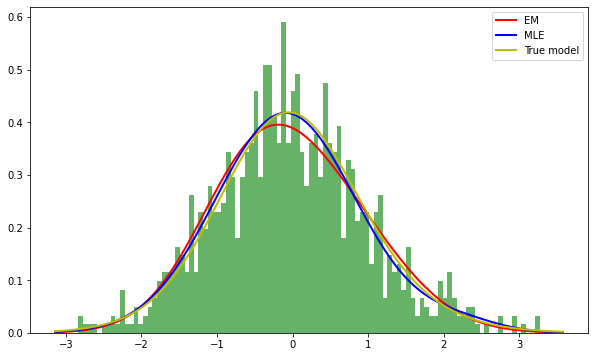

In [191]:
plt.figure(figsize=(10,6))
plt.hist(data, bins=100, density=True, alpha=0.6, color='g')

# EM
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = gmm.weights_[0] * norm.pdf(x, gmm.means_[0][0], np.sqrt(gmm.covariances_[0][0][0])) + \
    gmm.weights_[1] * norm.pdf(x, gmm.means_[1][0], np.sqrt(gmm.covariances_[1][0][0]))
plt.plot(x, p, 'k', linewidth=2,label = 'EM',color='r')

# MLE
p = res.x[4] * norm.pdf(x, res.x[0], res.x[2]) + \
    (1-res.x[4]) * norm.pdf(x, res.x[1], res.x[3])
plt.plot(x, p, 'k', linewidth=2,label = 'MLE',color='b')

#True Model
p = p1 * norm.pdf(x, u1, sigma_1_2**0.5) + \
    p2 * norm.pdf(x, u2, sigma_2_2**0.5)
plt.plot(x, p, 'k', linewidth=2,label = 'True model',color='y')
plt.legend ()
plt.show()

Calculate KL divergences between true model and EM/MLE model.

In [189]:
def kl_monte_carlo(params1, params2, num_samples=10**6):
    mu1_1, mu2_1, sigma1_1, sigma2_1, p1_1 = params1
    mu1_2, mu2_2, sigma1_2, sigma2_2, p1_2 = params2
    
    p2_1 = 1 - p1_1
    p2_2 = 1 - p1_2

    # Define the pdfs for each mixture of Gaussians
    def pdf_1(x):
        return p1_1 * norm.pdf(x, mu1_1, sigma1_1) + p2_1 * norm.pdf(x, mu2_1, sigma2_1)

    def pdf_2(x):
        return p1_2 * norm.pdf(x, mu1_2, sigma1_2) + p2_2 * norm.pdf(x, mu2_2, sigma2_2)
    
    # Sample from the first distribution
    Z = np.random.binomial(n=1, p=p1_1, size=num_samples)
    samples = Z * np.random.normal(mu1_1, sigma1_1, num_samples) + \
               (1-Z) * np.random.normal(mu2_1, sigma2_1, num_samples)
    
    # Calculate the Monte Carlo estimate of the KL divergence
    kl_divergence = np.mean(np.log(pdf_1(samples) / pdf_2(samples)))
    return kl_divergence

In [204]:
true_params = [u1, u2, sigma_1_2**0.5, sigma_2_2**0.5, p1]
EM_params =list(gmm.means_.ravel())+list(np.square(gmm.covariances_.ravel()))+ [gmm.weights_.ravel()[0]]
print('KL divergence between True model and EM : ',kl_monte_carlo(true_params, EM_params))
print('KL divergence between True model and MLE : ',kl_monte_carlo(true_params, res.x))

KL divergence between True model and EM :  0.3235318821838568
KL divergence between True model and MLE :  0.003148793295736422


Some findings:

MLE estimation is closer to true model than EM's. 

Although those distributions are similar, the value of distributional parameters are quit different. 

In [104]:
best_aic = 400
best_summary = None
for i in range(500):
    starting_values = np.concatenate( (np.array(gjr_normal.params),dparams )   )
    sparch21 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=2, o=2, q=1,lags=lags)
    sparch21.distribution = MixNormal()
    '''    try:
        gjr_MixNormal=sparch21.fit(disp='off',cov_type=cov,options=options,starting_values=starting_values )
          # If the fitting is successful, break the loop
    except:'''
    gjr_MixNormal=sparch21.fit(disp='off',cov_type=cov,options=options,starting_values=starting_values )
    if best_aic > gjr_MixNormal.aic:
        best_params = np.array(gjr_MixNormal.params)
        best_aic = gjr_MixNormal.aic
        best_summary = gjr_MixNormal.summary()
        print(best_summary)
    dparams =  np.array(  [ np.random.uniform(),np.random.uniform()*10-5, np.random.uniform()] )
                       
        
best_summary

NameError: name 'gjr_normal' is not defined

In [107]:
Y = sample_data['Inflation shock']
mean='Zero'
best_aic = 400
best_init_val = []
best_summary = 0
for p1 in np.linspace(0.5, 1, 10):
    for mu1 in np.linspace(-2, 2, 10):
        for sigma in np.linspace(0.001, 1.2, 10):
            warnings.filterwarnings("ignore")
            model = SPARCH(Y,[p1,mu1,sigma],mean='Zero', vol='GARCH',p=1,q=1,lags=None,cov = 'robust')
            warnings.filterwarnings("default")
            if model.aic < best_aic:
                best_aic = model.aic
                best_init_val = [p1,mu1,sigma]
                best_summary = model.summary()
                
best_summary

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequal

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step,

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step,

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bo

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 4. The mess

...

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bo

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bo

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bo

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bo

<class 'statsmodels.iolib.summary.Summary'>
"""
                                Zero Mean - GARCH Model Results                                
===============================================================================================
Dep. Variable:                         Inflation shock   R-squared:                       0.000
Mean Model:                                  Zero Mean   Adj. R-squared:                  0.005
Vol Model:                                       GARCH   Log-Likelihood:               -172.182
Distribution:      Mixture of two Normal distributions   AIC:                           356.365
Method:                             Maximum Likelihood   BIC:                           376.390
                                                         No. Observations:                  208
Date:                                 Tue, Jul 25 2023   Df Residuals:                      208
Time:                                         16:12:52   Df Model:                            0
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1248  8.977e-02      1.390      0.165 [-5.117e-02,  0.301]
alpha[1]       0.6855      0.161      4.264  2.012e-05    [  0.370,  1.001]
beta[1]        0.3145      0.173      1.817  6.926e-02 [-2.479e-02,  0.654]
                                Distribution                               
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
p_1            0.0396  3.884e-02      1.021      0.307 [-3.649e-02,  0.116]
mu_1          -2.3877      3.098     -0.771      0.441    [ -8.459,  3.684]
sigma_1^2     11.1507      9.578      1.164      0.244    [ -7.621, 29.923]
===========================================================================

Covariance estimator: robust
"""

In [109]:
best_init_val

[0.6666666666666666, 0.22222222222222232, 1.2]

In [115]:
sp = SPARCH(Y,[0.3, -0.22, 0.7],mean='Zero', vol='GARCH',p=2,o=2,q=1,lags=None,cov = 'robust')

D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


In [117]:
sp.params[-3:]

p_1          0.897803
mu_1         0.053604
sigma_1^2    0.484835
Name: params, dtype: float64

In [118]:
print_param(sp.params[-3:])

Mixture of 2 normals parameters: 
Probabilities:  [0.8978033819348371, 0.10219661806516289]
Means:  [0.05360433683747355, -0.4709172946248729]
Variances:  [0.4848352534155553, 3.355787871637773]


In [119]:
sp

                              Zero Mean - GJR-GARCH Model Results                              
Dep. Variable:                         Inflation shock   R-squared:                       0.000
Mean Model:                                  Zero Mean   Adj. R-squared:                  0.005
Vol Model:                                   GJR-GARCH   Log-Likelihood:               -165.181
Distribution:      Mixture of two Normal distributions   AIC:                           348.363
Method:                             Maximum Likelihood   BIC:                           378.401
                                                         No. Observations:                  208
Date:                                 Tue, Jul 25 2023   Df Residuals:                      208
Time:                                         16:17:43   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.